In [3]:
import pandas as pd

train_df = pd.read_csv("../data/train_data.csv")
test_df = pd.read_csv("../data/test_data.csv")

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

train_df.head()

Train Shape: (841, 2)
Test Shape: (150, 2)


,Genre,Poem
0,Music,NaN
1,Music,In the thick brushthey spend the...
2,Music,Storms are generous. ...
3,Music,—After Ana Mendieta Did you carry around the ...
4,Music,for Aja Sherrard at 20The portent may itself ...


In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 841 entries, 0 to 840
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Genre   841 non-null    str  
 1   Poem    837 non-null    str  
dtypes: str(2)
memory usage: 13.3 KB


In [5]:
train_df.isnull().sum()

Genre    0
Poem     4
dtype: int64

In [6]:
train_df = train_df.dropna()

In [7]:
train_df.duplicated().sum()

np.int64(2)

In [8]:
train_df = train_df.drop_duplicates()

In [10]:
train_df["Genre"].value_counts()

Genre
Music          238
Death          229
Environment    227
Affection      141
Name: count, dtype: int64

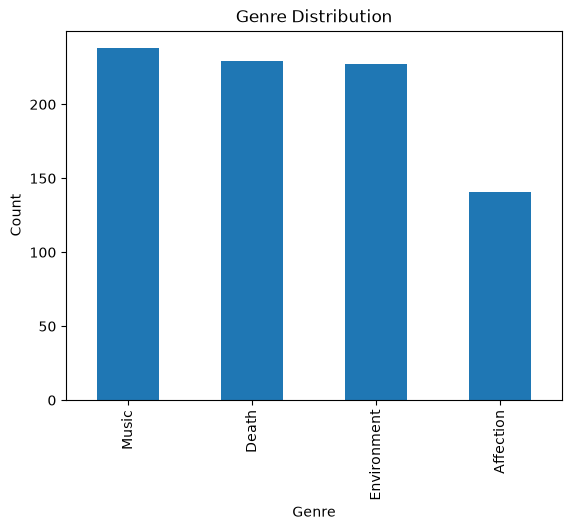

In [11]:
import matplotlib.pyplot as plt

train_df["Genre"].value_counts().plot(
    kind="bar"
)

plt.title("Genre Distribution")
plt.ylabel("Count")
plt.show()

In [12]:
train_df["char_count"] = train_df["Poem"].apply(len)

train_df["char_count"].describe()

count    835.000000
mean     269.035928
std       75.396943
min       14.000000
25%      245.000000
50%      288.000000
75%      317.000000
max      469.000000
Name: char_count, dtype: float64

In [13]:
train_df.groupby("Genre")["char_count"].mean()

Genre
Affection      273.042553
Death          276.847162
Environment    262.643172
Music          265.243697
Name: char_count, dtype: float64

In [14]:
train_df["word_count"]=train_df["Poem"].apply(
  lambda x:len(str(x).split())
)

train_df["word_count"].describe()

count    835.000000
mean      46.629940
std       12.560103
min        3.000000
25%       43.000000
50%       50.000000
75%       55.000000
max       69.000000
Name: word_count, dtype: float64

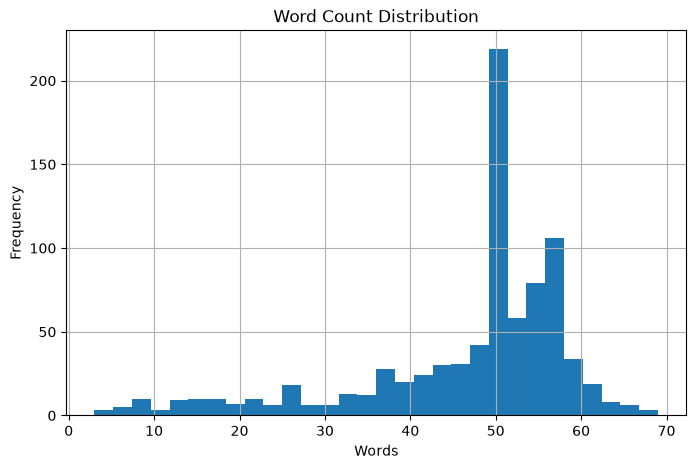

In [15]:
plt.figure(figsize=(8,5))

train_df["word_count"].hist(
    bins=30
)

plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [16]:
train_df.groupby("Genre")["word_count"].mean()

Genre
Affection      48.021277
Death          48.379913
Environment    44.400881
Music          46.247899
Name: word_count, dtype: float64

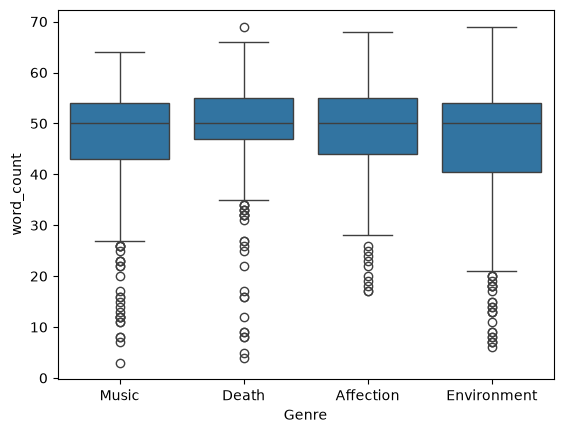

In [17]:
import seaborn as sns

sns.boxplot(
    data=train_df,
    x="Genre",
    y="word_count"
)

plt.show()

In [18]:
from collections import Counter

all_words = " ".join(train_df["Poem"]).split()

Counter(all_words).most_common(20)

[('the', 2370),
 ('a', 929),
 ('of', 900),
 ('and', 836),
 ('I', 699),
 ('to', 695),
 ('in', 641),
 ('is', 369),
 ('my', 349),
 ('with', 260),
 ('The', 244),
 ('that', 243),
 ('you', 234),
 ('for', 230),
 ('it', 224),
 ('on', 218),
 ('from', 192),
 ('as', 190),
 ('not', 185),
 ('was', 184)]

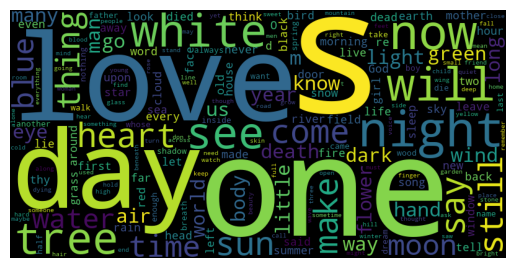

In [19]:
from wordcloud import WordCloud

text = " ".join(train_df["Poem"])

wc = WordCloud(
    width=800,
    height=400
).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()

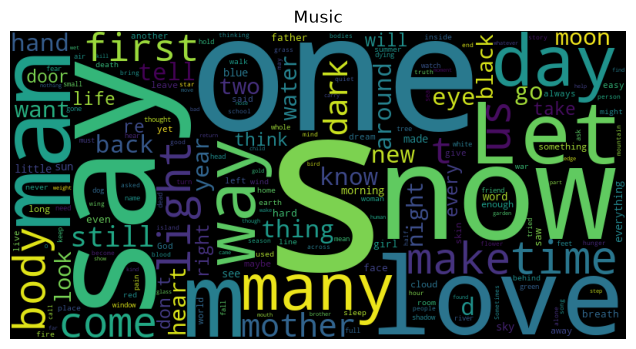

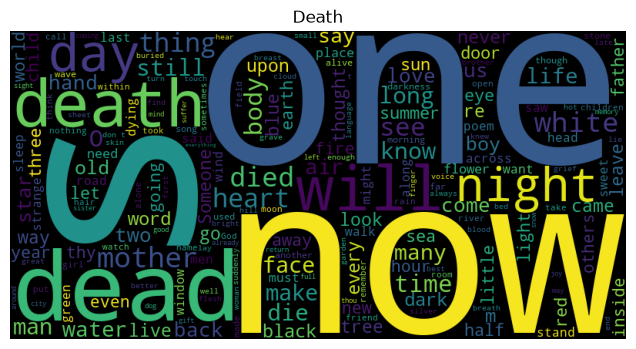

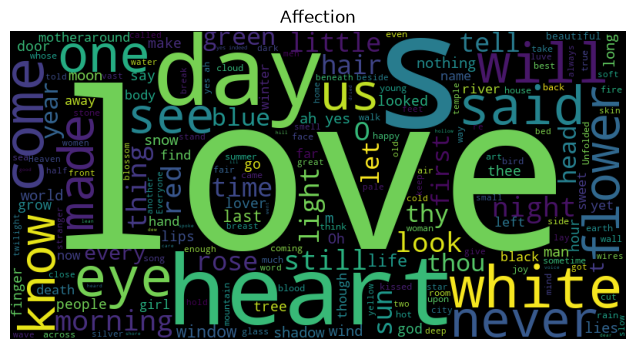

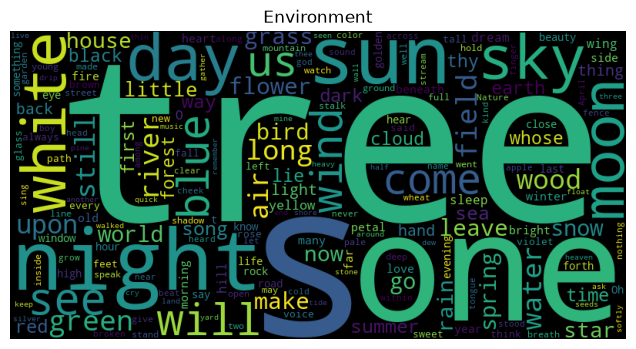

In [20]:
for genre in train_df["Genre"].unique():

    text = " ".join(
        train_df[
            train_df["Genre"] == genre
        ]["Poem"]
    )

    wc = WordCloud(
        width=800,
        height=400
    ).generate(text)

    plt.figure(figsize=(8,4))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(genre)
    plt.show()

In [21]:
(train_df["Genre"].value_counts(normalize=True) * 100).round(2)

Genre
Music          28.50
Death          27.43
Environment    27.19
Affection      16.89
Name: proportion, dtype: float64

In [22]:
all_words = " ".join(train_df["Poem"]).lower().split()

print("Vocabulary Size:", len(set(all_words)))

Vocabulary Size: 11404


In [23]:
from collections import Counter

for genre in train_df["Genre"].unique():

    text = " ".join(
        train_df[train_df["Genre"] == genre]["Poem"]
    ).lower()

    words = text.split()

    print("\n", genre)
    print(Counter(words).most_common(10))


 Music
[('the', 679), ('a', 304), ('of', 249), ('to', 238), ('i', 236), ('and', 225), ('in', 195), ('my', 133), ('is', 113), ('you', 92)]

 Death
[('the', 646), ('a', 288), ('and', 280), ('of', 256), ('i', 223), ('to', 213), ('in', 182), ('my', 110), ('is', 99), ('with', 91)]

 Affection
[('the', 450), ('and', 195), ('a', 160), ('of', 144), ('in', 126), ('i', 124), ('to', 123), ('my', 89), ('that', 77), ('is', 67)]

 Environment
[('the', 841), ('and', 284), ('of', 266), ('a', 249), ('in', 207), ('to', 173), ('i', 141), ('is', 99), ('it', 77), ('with', 68)]


In [24]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(
    stop_words='english',
    ngram_range=(2,2)
)

X = cv.fit_transform(train_df["Poem"])

freq = X.sum(axis=0).A1

ngrams = zip(cv.get_feature_names_out(), freq)

sorted(ngrams, key=lambda x: x[1], reverse=True)[:20]

[('don know', np.int64(9)),
 ('ah yes', np.int64(8)),
 ('let say', np.int64(6)),
 ('parking lot', np.int64(6)),
 ('august 2015', np.int64(5)),
 ('did know', np.int64(5)),
 ('died august', np.int64(5)),
 ('thou art', np.int64(5)),
 ('yes ah', np.int64(5)),
 ('best heart', np.int64(4)),
 ('blue face', np.int64(4)),
 ('dead man', np.int64(4)),
 ('footstep coming', np.int64(4)),
 ('like sun', np.int64(4)),
 ('long ago', np.int64(4)),
 ('oh pleasure', np.int64(4)),
 ('pulse heart', np.int64(4)),
 ('river like', np.int64(4)),
 ('say did', np.int64(4)),
 ('ancient symbolswe', np.int64(3))]

In [25]:
train_df.to_csv("../data/train_eda.csv", index=False)
test_df.to_csv("../data/test_eda.csv", index=False)